In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

In [2]:
forecasted_temps=pd.read_csv("../DataFrames/forcastedTemps(2023-2025).csv")
forecasted_temps.drop(columns={"Unnamed: 0"}, inplace=True)

forecasted_temps["ds"]=pd.to_datetime(forecasted_temps["ds"])

#forecasted_2023=forecasted_temps[forecasted_temps["ds"].dt.year==2023].reset_index(drop=True)
#forecasted_2024=forecasted_temps[forecasted_temps["ds"].dt.year==2024].reset_index(drop=True)
#forecasted_2025=forecasted_temps[forecasted_temps["ds"].dt.year==2025].reset_index(drop=True)
print(forecasted_temps)

             ds       yhat
0    2023-01-01  35.535912
1    2023-01-02  35.455584
2    2023-01-03  35.505547
3    2023-01-04  35.379355
4    2023-01-05  35.237120
...         ...        ...
1091 2025-12-27  36.075685
1092 2025-12-28  35.991556
1093 2025-12-29  35.897991
1094 2025-12-30  35.938553
1095 2025-12-31  35.806586

[1096 rows x 2 columns]


In [3]:
real_temps=pd.read_csv("../DataFrames/NY_AvgTemp(2023-2025).csv")


real_temps=real_temps[real_temps["county_name"]=="New York"]
real_temps=real_temps[["date", "tavg"]]
real_temps["date"]=real_temps["date"].astype("string")
real_temps["date"]=real_temps["date"].str[:4]+'-'+real_temps["date"].str[4:6]+'-'+real_temps["date"].str[6:]
real_temps["date"]=pd.to_datetime(real_temps["date"])
real_temps["tavg"]=(real_temps["tavg"]*1.8)+30

real_2023=real_temps[real_temps["date"].dt.year==2023].reset_index(drop=True)
real_2023.to_csv("../DataFrames/real_2023Temp.csv")
#real_2024=real_temps[real_temps["date"].dt.year==2024].reset_index(drop=True)
#real_2025=real_temps[real_temps["date"].dt.year==2025].reset_index(drop=True)



C:\Users\fdram\AppData\Local\Temp\ipykernel_9660\1986243195.py:1: DtypeWarning: Columns (0: stability) have mixed types. Specify dtype option on import or set low_memory=False.
  real_temps=pd.read_csv("../DataFrames/NY_AvgTemp(2023-2025).csv")


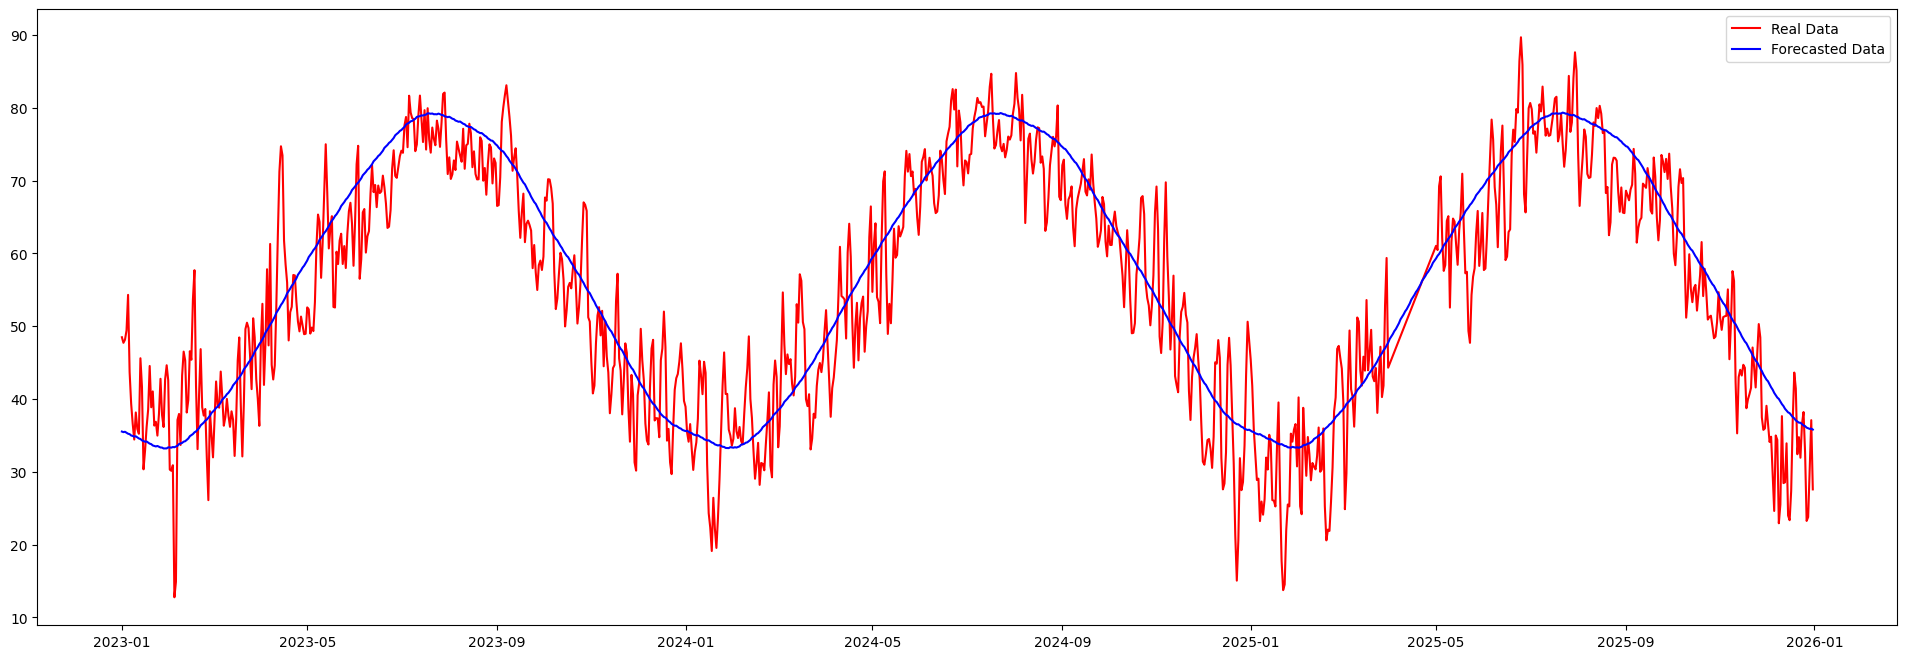

In [4]:
#Graphing both the real and forecasted temperatures for 2023
plt.figure(figsize=(24, 8))
plt.plot(real_temps["date"], real_temps["tavg"], color='red', label='Real Data' )
plt.plot(forecasted_temps['ds'], forecasted_temps["yhat"], color='blue', label='Forecasted Data' )
plt.legend()

In [5]:
df_1896_1899=pd.read_csv("../DataFrames/NYC_Central_Park_weather_1869-2022.csv")
df_1896_1899["DATE"]=pd.to_datetime(df_1896_1899["DATE"])
df_1896_1899=df_1896_1899[(df_1896_1899["DATE"].dt.year>=1896) & (df_1896_1899["DATE"].dt.year<1899)].reset_index(drop=True)
df_1896_1899["Temp"]=(df_1896_1899["TMIN"]+df_1896_1899["TMAX"])/2
df_1896=df_1896_1899[["DATE", "Temp"]]
print(df_1896_1899)


           DATE  PRCP  SNOW  SNWD  TMIN  TMAX  Temp
0    1896-01-01  0.00   0.0   NaN  26.0  34.0  30.0
1    1896-01-02  0.00   0.0   NaN  26.0  46.0  36.0
2    1896-01-03  0.00   0.0   NaN  24.0  45.0  34.5
3    1896-01-04  0.00   0.0   NaN  13.0  24.0  18.5
4    1896-01-05  0.00   0.0   NaN   6.0  18.0  12.0
...         ...   ...   ...   ...   ...   ...   ...
1091 1898-12-27  0.00   0.0   NaN  31.0  38.0  34.5
1092 1898-12-28  0.00   0.0   NaN  19.0  34.0  26.5
1093 1898-12-29  0.00   0.0   NaN  26.0  45.0  35.5
1094 1898-12-30  0.00   0.0   NaN  43.0  57.0  50.0
1095 1898-12-31  0.36   1.0   NaN  18.0  53.0  35.5

[1096 rows x 7 columns]


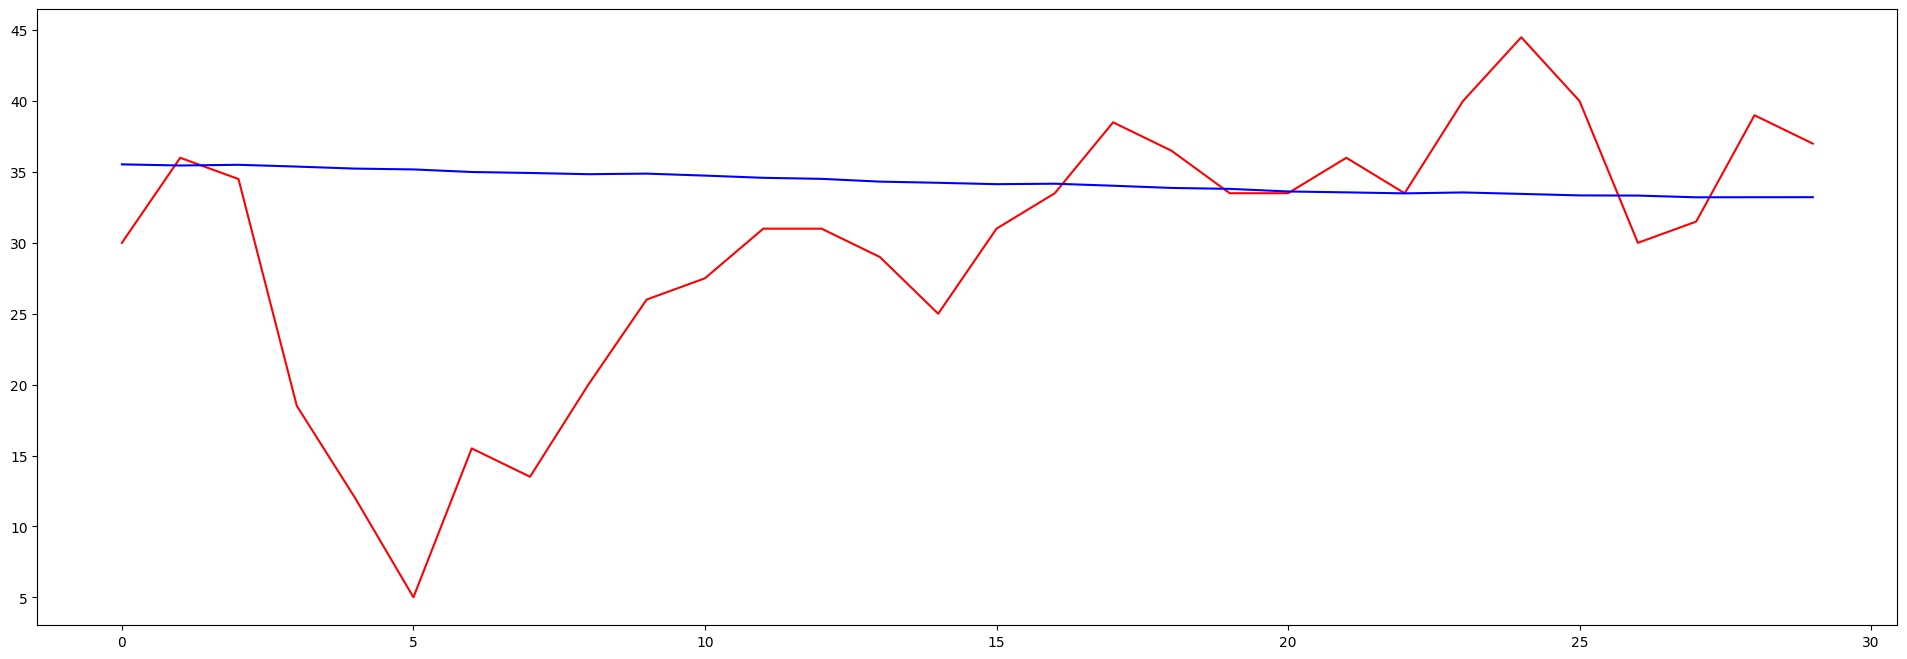

In [57]:
plt.figure(figsize=(24, 8))
plt.plot(df_1896_1899.index[:30], df_1896_1899["Temp"][:30], color='red', label='Real Data' )
plt.plot(forecasted_temps.index[:30], forecasted_temps["yhat"][:30], color='blue', label='Forecasted Data' )

In [ ]:
plt.figure(figsize=(24, 8))
plt.plot(df_1896_1899.index, df_1896_1899["Temp"], color='red', label='Real Data' )
plt.plot(forecasted_temps.index, forecasted_temps["yhat"], color='blue', label='Forecasted Data' )

In [23]:
real_temps_Avg=real_temps.groupby(real_temps["date"].dt.year)["tavg"].mean()
print(real_temps_Avg)

yearlyAvg_1896_1899=df_1896_1899.groupby(df_1896_1899["DATE"].dt.year)["Temp"].mean()
print(yearlyAvg_1896_1899)

date
2023    55.344444
2024    55.401413
2025    53.971942
Name: tavg, dtype: float64
DATE
1896    53.676230
1897    53.724658
1898    55.158904
Name: Temp, dtype: float64


In [31]:
real_avg_per_Year=pd.read_csv("../DataFrames/tempByYear.csv", index_col="Unnamed: 0")
print(real_avg_per_Year.head())
all_forecasts=pd.read_csv("..//DataFrames/forcastedTemps(1869-2176).csv", index_col='Unnamed: 0')
all_forecasts['ds']=pd.to_datetime(all_forecasts['ds'])
#print(all_forecasts.info())
all_forecasts_per_Year=all_forecasts.groupby(all_forecasts['ds'].dt.year)['yhat'].mean().reset_index()
print(all_forecasts_per_Year.head())

   Year    TempAvg
0  1869  51.809012
1  1870  53.690351
2  1871  51.302631
3  1872  51.320184
4  1873  50.779887
     ds       yhat
0  1869  52.000675
1  1870  51.972928
2  1871  51.945496
3  1872  51.861232
4  1873  51.890779


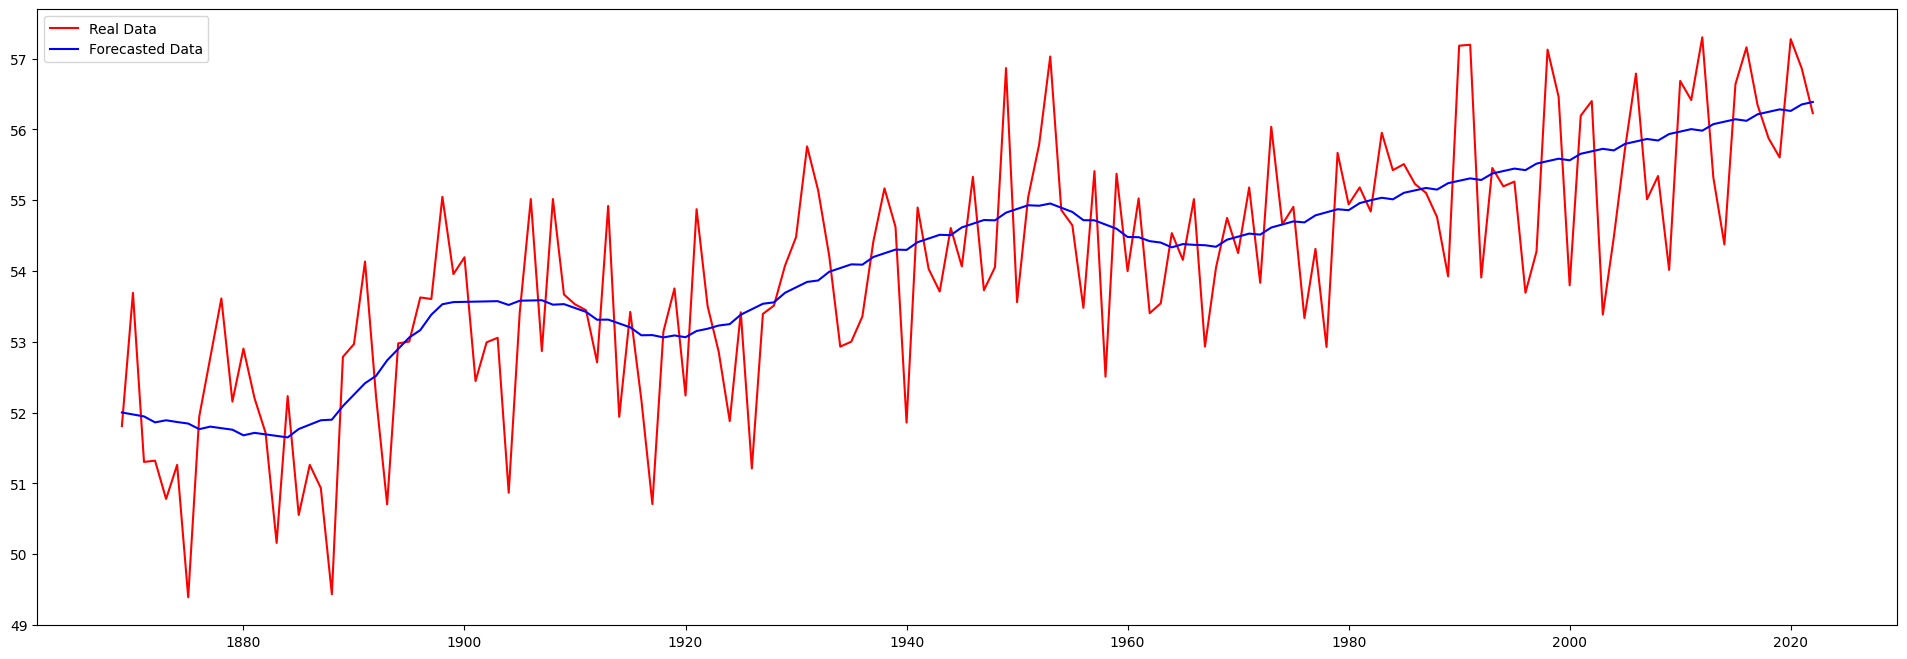

In [39]:
plt.figure(figsize=(24, 8))
plt.plot(real_avg_per_Year["Year"][:154], real_avg_per_Year["TempAvg"][:154], color='red', label='Real Data' )
plt.plot(all_forecasts_per_Year["ds"][:154], all_forecasts_per_Year["yhat"][:154], color='blue', label='Forecasted Data' )

plt.legend()

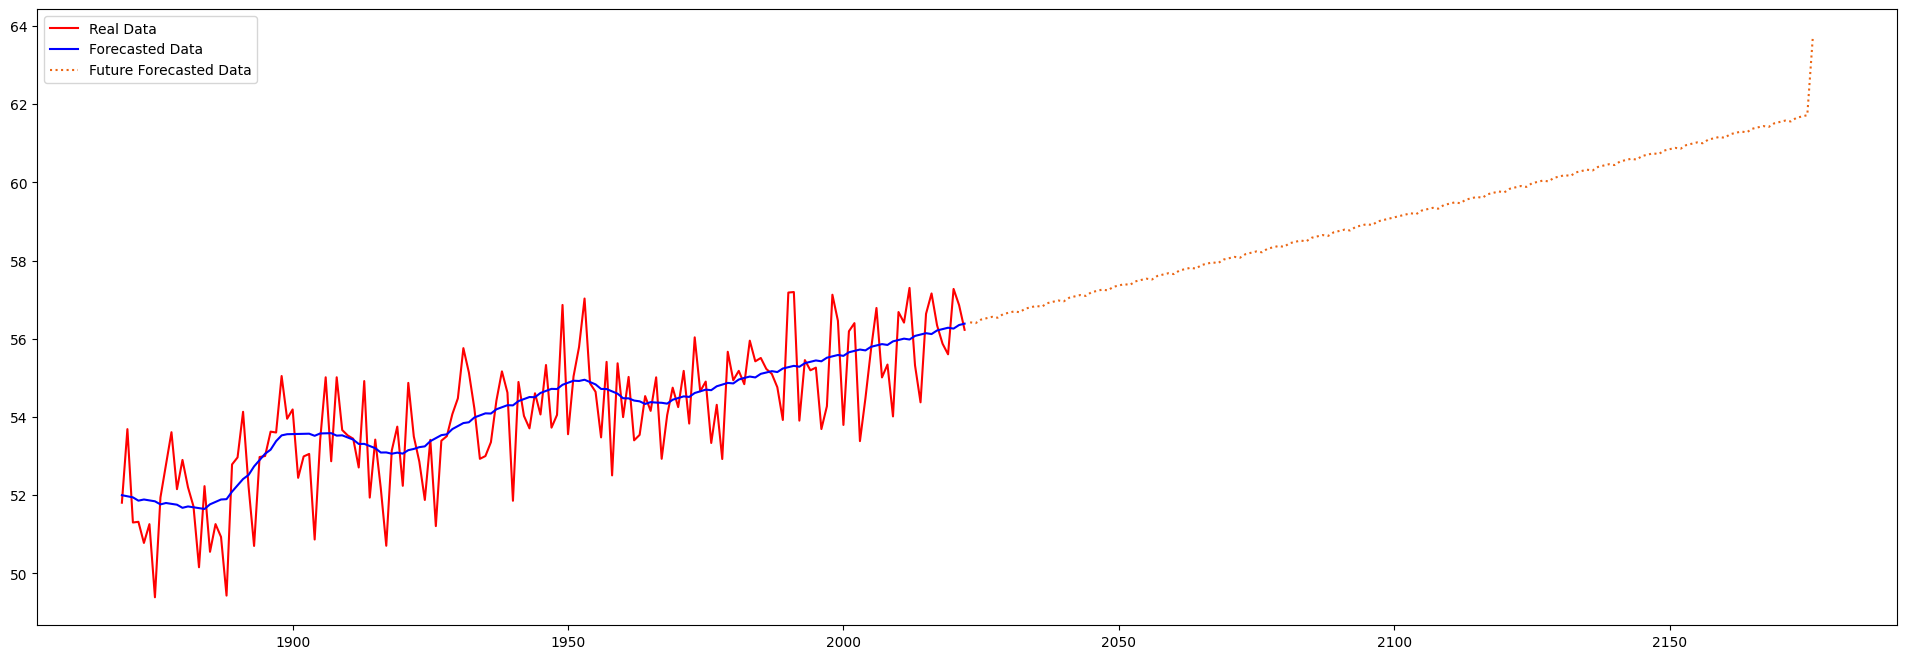

In [51]:
plt.figure(figsize=(24, 8))
plt.plot(real_avg_per_Year["Year"][:154], real_avg_per_Year["TempAvg"][:154], color='red', label='Real Data' )
plt.plot(all_forecasts_per_Year["ds"][:154], all_forecasts_per_Year["yhat"][:154], color='blue', label='Forecasted Data' )
plt.plot(all_forecasts_per_Year["ds"][154:], all_forecasts_per_Year["yhat"][154:], color="#eb6614", linestyle='dotted', label='Future Forecasted Data' )
plt.legend()

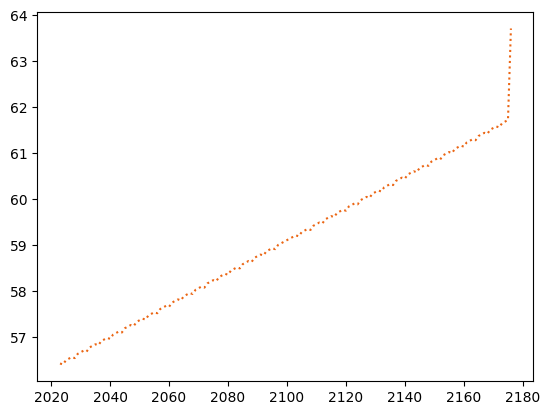

In [52]:
plt.plot(all_forecasts_per_Year["ds"][154:], all_forecasts_per_Year["yhat"][154:], color="#eb6614", linestyle='dotted', label='Future Forecasted Data' )
